# CMP500 Brain Trait Correlation Analysis

Computes Pearson correlations between parent-child brain trait distances and displacement improvement (Δf).

Two analyses are shown side-by-side:
- **Pooled** — all pairs combined (original approach)
- **Per-run** — one r per run (n=10 per condition, independent, correct unit of replication)

In [18]:
import json
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import mannwhitneyu, pearsonr

REPO_ROOT = Path("..").resolve()   # experiments/ -> evogym-GRN/
sys.path.append(str(REPO_ROOT))

from algorithms.GRN_2D import GRN

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: /Users/augustincoman/Empire/Uni stuff/thesis-code/evogym-GRN


In [19]:
STUDY_ROOT = REPO_ROOT / "tmp_out" / "thesis"
CONDITIONS = {
    "tf67":     {"experiment": "cmp500_tf67"},
    "original": {"experiment": "cmp500_original"},
}
N_RUNS     = 10
BRAIN_COLS = ["phase_mean", "phase_std", "amp_mean", "amp_std"]
DIST_COLS  = ["brain_dist", "phase_dist", "amp_dist"]
COLORS     = {"tf67": "#4488CC", "original": "#CC4444"}

In [20]:
def brain_summary(genome_list):
    grn = GRN(promoter_threshold=0.95, max_voxels=27, cube_face_size=4,
              voxel_types="withbone", genotype=genome_list)
    grn.develop()
    muscle_types = {
        grn.structural_products.get("phase_muscle"),
        grn.structural_products.get("offphase_muscle"),
    }
    mask = np.zeros(grn.phenotype.shape, dtype=bool)
    for idx, cell in np.ndenumerate(grn.phenotype):
        if cell != 0 and cell.voxel_type in muscle_types:
            mask[idx] = True
    if not mask.any():
        return [np.nan] * 4
    phases = grn.phase_map[mask]
    amps   = grn.amplitude_map[mask]
    return [float(phases.mean()), float(phases.std()),
            float(amps.mean()),   float(amps.std())]


def load_condition(cond_name, experiment):
    rows = []
    for run in range(1, N_RUNS + 1):
        db = STUDY_ROOT / experiment / f"run_{run}" / f"run_{run}"
        con = sqlite3.connect(db)
        df = pd.read_sql("""
            SELECT robot_id, genome, parent1_id, parent2_id, displacement
            FROM all_robots
        """, con)
        con.close()
        df["condition"]    = cond_name
        df["run"]          = run
        df["uid"]          = df.apply(lambda r: f"{cond_name}_{run}_{int(r.robot_id)}", axis=1)
        df["parent1_uid"]  = df.apply(
            lambda r: f"{cond_name}_{run}_{int(r.parent1_id)}" if pd.notna(r.parent1_id) else None, axis=1)
        df["parent2_uid"]  = df.apply(
            lambda r: f"{cond_name}_{run}_{int(r.parent2_id)}" if pd.notna(r.parent2_id) else None, axis=1)
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

In [21]:
print("Loading data...")
dfs = []
for cond_name, cfg in CONDITIONS.items():
    df = load_condition(cond_name, cfg["experiment"])
    print(f"  {cond_name}: {len(df):,} robots across {N_RUNS} runs")
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df):,} robots")

Loading data...
  tf67: 150,000 robots across 10 runs
  original: 150,000 robots across 10 runs

Total: 300,000 robots


In [22]:
import multiprocessing as mp

def _brain_worker(genome):
    g = json.loads(genome) if isinstance(genome, str) else genome
    return brain_summary(g)

n_workers  = mp.cpu_count()
n_robots   = len(df)
batch_size = 10_000
print(f"Computing brain traits for {n_robots:,} robots using {n_workers} workers...")

genomes   = df["genome"].tolist()
summaries = []
done      = 0

ctx = mp.get_context("fork")
with ctx.Pool(n_workers) as pool:
    for start in range(0, n_robots, batch_size):
        chunk = genomes[start:start + batch_size]
        summaries.extend(pool.map(_brain_worker, chunk, chunksize=200))
        done += len(chunk)
        print(f"  {done:,} / {n_robots:,}  ({100 * done / n_robots:.1f}%)", flush=True)

df[BRAIN_COLS] = pd.DataFrame(summaries, index=df.index)
print("Done.")
print(df[BRAIN_COLS].describe().round(3))

Computing brain traits for 300,000 robots using 10 workers...
  10,000 / 300,000  (3.3%)
  20,000 / 300,000  (6.7%)
  30,000 / 300,000  (10.0%)


Exception ignored in: <function tqdm.__del__ at 0x32a326820>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/evogym/lib/python3.9/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/miniconda3/envs/evogym/lib/python3.9/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


  40,000 / 300,000  (13.3%)
  50,000 / 300,000  (16.7%)
  60,000 / 300,000  (20.0%)
  70,000 / 300,000  (23.3%)
  80,000 / 300,000  (26.7%)
  90,000 / 300,000  (30.0%)
  100,000 / 300,000  (33.3%)
  110,000 / 300,000  (36.7%)
  120,000 / 300,000  (40.0%)
  130,000 / 300,000  (43.3%)
  140,000 / 300,000  (46.7%)
  150,000 / 300,000  (50.0%)
  160,000 / 300,000  (53.3%)
  170,000 / 300,000  (56.7%)
  180,000 / 300,000  (60.0%)
  190,000 / 300,000  (63.3%)
  200,000 / 300,000  (66.7%)
  210,000 / 300,000  (70.0%)
  220,000 / 300,000  (73.3%)
  230,000 / 300,000  (76.7%)
  240,000 / 300,000  (80.0%)
  250,000 / 300,000  (83.3%)
  260,000 / 300,000  (86.7%)
  270,000 / 300,000  (90.0%)
  280,000 / 300,000  (93.3%)
  290,000 / 300,000  (96.7%)
  300,000 / 300,000  (100.0%)
Done.
       phase_mean   phase_std    amp_mean     amp_std
count  300000.000  300000.000  300000.000  300000.000
mean        1.372       1.496       0.233       0.130
std         1.407       1.340       0.122       0.105


In [ ]:
# Z-score within each condition across all runs
df = df.copy()
for cond in df["condition"].unique():
    m = df["condition"] == cond
    for col in BRAIN_COLS:
        mu  = df.loc[m, col].mean()
        sig = df.loc[m, col].std()
        df.loc[m, col + "_z"] = (df.loc[m, col] - mu) / sig

print("Z-scored brain traits per condition.")

Z-scored brain traits per condition.


In [24]:
z_cols    = [c + "_z" for c in BRAIN_COLS]
id_lookup = df.set_index("uid")[z_cols + ["displacement"]].to_dict("index")

total = len(df)
print(f"Building parent-child pairs from {total:,} robots...")
rows = []
for i, (_, child) in enumerate(df.iterrows()):
    for puid_col in ["parent1_uid", "parent2_uid"]:
        puid = child[puid_col]
        if pd.isna(puid) or puid not in id_lookup:
            continue
        p      = id_lookup[puid]
        c_disp = float(child["displacement"])
        p_disp = float(p["displacement"])
        if not (np.isfinite(c_disp) and np.isfinite(p_disp)):
            continue
        c_vec = np.array([child[c] for c in z_cols], dtype=float)
        p_vec = np.array([p[c]     for c in z_cols], dtype=float)
        if np.any(np.isnan(c_vec)) or np.any(np.isnan(p_vec)):
            continue
        diff = c_vec - p_vec
        rows.append({
            "brain_dist": np.linalg.norm(diff),
            "phase_dist": np.linalg.norm(diff[:2]),
            "amp_dist":   np.linalg.norm(diff[2:]),
            "delta_f":    c_disp - p_disp,
            "condition":  child["condition"],
            "run":        child["run"],
        })
    if (i + 1) % 50000 == 0:
        print(f"  {i + 1:,} / {total:,}  ({100*(i+1)/total:.0f}%)", flush=True)

pairs_df = pd.DataFrame(rows)
tf_n  = len(pairs_df[pairs_df.condition == "tf67"])
ori_n = len(pairs_df[pairs_df.condition == "original"])
print(f"Done. Valid pairs — tf67: {tf_n:,}  |  original: {ori_n:,}")

Building parent-child pairs from 300,000 robots...
  50,000 / 300,000  (17%)
  100,000 / 300,000  (33%)
  150,000 / 300,000  (50%)
  200,000 / 300,000  (67%)
  250,000 / 300,000  (83%)
  300,000 / 300,000  (100%)
Done. Valid pairs — tf67: 238,634  |  original: 249,484


## Pooled correlations (original)

All pairs pooled per condition. Note: observations are **not independent** - pairs come from the same lineages across 10 runs.

In [25]:
pooled_rows = []
for cond in ["tf67", "original"]:
    sub = pairs_df[pairs_df["condition"] == cond]
    row = {"condition": cond, "n_pairs": len(sub)}
    for dc in DIST_COLS:
        r, p = pearsonr(sub[dc], sub["delta_f"])
        row[f"r_{dc}"] = round(r, 3)
        row[f"p_{dc}"] = f"{p:.2e}"
    pooled_rows.append(row)

pooled_df = pd.DataFrame(pooled_rows)
display(pooled_df.set_index("condition"))

,n_pairs,r_brain_dist,p_brain_dist,r_phase_dist,p_phase_dist,r_amp_dist,p_amp_dist
condition,,,,,,,
tf67,238634,-0.436,0.00e+00,-0.316,0.00e+00,-0.351,0.00e+00
original,249484,-0.370,0.00e+00,-0.296,0.00e+00,-0.290,0.00e+00


## Per-run correlations (corrected analysis)

One Pearson r per run -> **n = 10** independent values per condition. This is the correct unit of replication.

In [26]:
perrun_rows = []
for cond in ["tf67", "original"]:
    for run in range(1, N_RUNS + 1):
        sub = pairs_df[(pairs_df["condition"] == cond) & (pairs_df["run"] == run)]
        if len(sub) < 10:
            print(f"[WARN] {cond} run {run}: only {len(sub)} pairs — skipping")
            continue
        row = {"condition": cond, "run": run, "n_pairs": len(sub)}
        for dc in DIST_COLS:
            r, _ = pearsonr(sub[dc], sub["delta_f"])
            row[f"r_{dc}"] = r
        perrun_rows.append(row)

perrun_df = pd.DataFrame(perrun_rows)
print(f"Computed per-run r for {len(perrun_df)} (condition, run) combinations")

Computed per-run r for 20 (condition, run) combinations


In [47]:
def styled_perrun(cond):
    sub = perrun_df[perrun_df["condition"] == cond].set_index("run")
    display_cols = ["n_pairs", "r_brain_dist", "r_phase_dist", "r_amp_dist"]
    out = sub[display_cols].copy()
    # append mean and std rows
    mean_row = out.mean(numeric_only=True).rename("mean")
    std_row  = out.std(numeric_only=True).rename("std")
    out = pd.concat([out, mean_row.to_frame().T, std_row.to_frame().T])
    return out.round(3)

print("-- TF6/7 --")
display(styled_perrun("tf67"))
print("-- Original --")
display(styled_perrun("original"))

-- TF6/7 --


,n_pairs,r_brain_dist,r_phase_dist,r_amp_dist
1,26921.000,-0.471,-0.328,-0.438
2,26471.000,-0.512,-0.429,-0.404
3,22384.000,-0.445,-0.314,-0.385
4,22906.000,-0.625,-0.594,-0.499
5,22686.000,-0.463,-0.261,-0.395
6,23804.000,-0.431,-0.259,-0.393
7,23348.000,-0.507,-0.427,-0.309
8,23352.000,-0.524,-0.366,-0.388
9,25274.000,-0.628,-0.483,-0.528
10,21488.000,-0.458,-0.275,-0.440


-- Original --


,n_pairs,r_brain_dist,r_phase_dist,r_amp_dist
1,27890.00,-0.401,-0.363,-0.302
2,26550.00,-0.353,-0.337,-0.263
3,25954.00,-0.449,-0.323,-0.447
4,26032.00,-0.331,-0.259,-0.280
5,23005.00,-0.378,-0.305,-0.287
6,25725.00,-0.353,-0.268,-0.243
7,19842.00,-0.526,-0.498,-0.391
8,24322.00,-0.327,-0.284,-0.284
9,23042.00,-0.342,-0.224,-0.303
10,27122.00,-0.397,-0.228,-0.303


## Condition comparison

Mann-Whitney U test on the 10 per-run r-values from each condition.

In [28]:
cmp_rows = []
tf  = perrun_df[perrun_df["condition"] == "tf67"]
ori = perrun_df[perrun_df["condition"] == "original"]

for dc in DIST_COLS:
    col = f"r_{dc}"
    a, b = tf[col].values, ori[col].values
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    cliff = (2 * u / (len(a) * len(b))) - 1
    cmp_rows.append({
        "distance":        dc,
        "tf67_mean":       round(a.mean(), 3),
        "tf67_std":        round(a.std(),  3),
        "original_mean":   round(b.mean(), 3),
        "original_std":    round(b.std(),  3),
        "U":               u,
        "p":               round(p, 4),
        "sig":             "*" if p < 0.05 else "",
        "cliff_delta":     round(cliff, 3),
    })

cmp_df = pd.DataFrame(cmp_rows)
display(cmp_df.set_index("distance"))

,tf67_mean,tf67_std,original_mean,original_std,U,p,sig,cliff_delta
distance,,,,,,,,
brain_dist,-0.506,0.066,-0.386,0.059,10.0,0.0028,*,-0.80
phase_dist,-0.374,0.104,-0.309,0.076,32.0,0.1859,,-0.36
amp_dist,-0.418,0.059,-0.310,0.059,11.0,0.0036,*,-0.78


/var/folders/y_/0_c8zmgs57ddcb1kbbpdl8f80000gn/T/ipykernel_72324/1693693000.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/y_/0_c8zmgs57ddcb1kbbpdl8f80000gn/T/ipykernel_72324/1693693000.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/y_/0_c8zmgs57ddcb1kbbpdl8f80000gn/T/ipykernel_72324/1693693000.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Figure saved → /Users/augustincoman/Empire/Uni stuff/thesis-code/evogym-GRN/tmp_out/thesis/figures/perrun_correlations.png


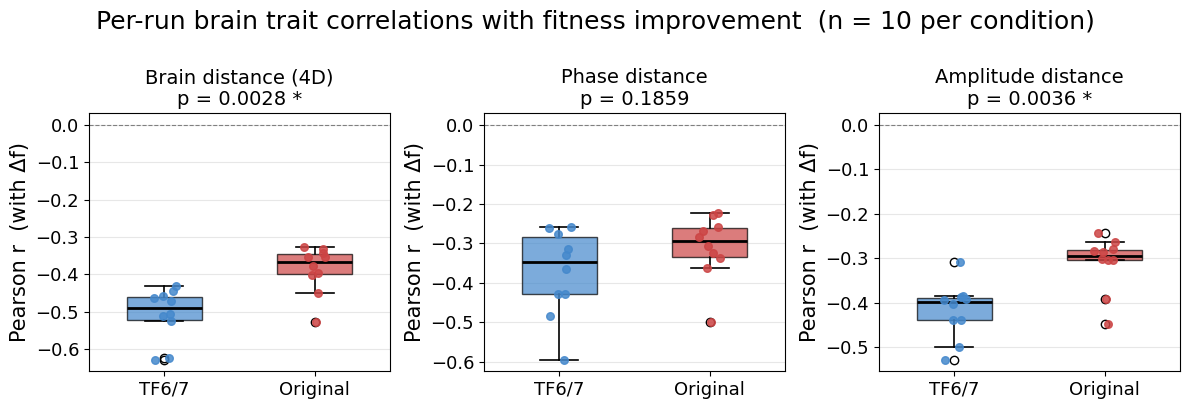

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
titles = {
    "r_brain_dist": "Brain distance (4D)",
    "r_phase_dist": "Phase distance",
    "r_amp_dist":   "Amplitude distance",
}

for ax, (col, title) in zip(axes, titles.items()):
    tf_vals  = tf[col].values
    ori_vals = ori[col].values

    bp = ax.boxplot(
        [tf_vals, ori_vals],
        labels=["TF6/7", "Original"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        widths=0.5,
    )
    for patch, key in zip(bp["boxes"], ["tf67", "original"]):
        patch.set_facecolor(COLORS[key])
        patch.set_alpha(0.7)

    rng = np.random.default_rng(42)
    for x, vals, key in zip([1, 2], [tf_vals, ori_vals], ["tf67", "original"]):
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(x + jitter, vals, color=COLORS[key], alpha=0.85, s=30, zorder=5)

    row = cmp_df[cmp_df["distance"] == col.replace("r_", "")].iloc[0]
    sig_str = f"p = {row.p:.4f}" + (" *" if row.sig else "")
    ax.set_title(f"{title}\n{sig_str}", fontsize=14)
    ax.set_ylabel("Pearson r  (with Δf)", fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-run brain trait correlations with fitness improvement  (n = 10 per condition)",
             fontsize=18, y=1.01)
fig.tight_layout()

out_fig = STUDY_ROOT / "figures" / "perrun_correlations.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_fig, dpi=200, bbox_inches="tight")
print(f"Figure saved → {out_fig}")
plt.show()

## Numbers to update in the paper

Replace the pooled Pearson r values in Table 1 and the Discussion with the per-run means below.
Replace the permutation test sentence with the Mann-Whitney U result on n=10 vs n=10.

In [48]:
print("=" * 60)
print("UPDATED NUMBERS FOR THE PAPER")
print("=" * 60)
print()
print("Table 1 replacement (per-run mean r):")
print(f"{'Condition':>10}  {'r_brain':>8}  {'r_phase':>8}  {'r_amp':>8}")
for cond, sub in [("original", ori), ("tf67", tf)]:
    print(f"{cond:>10}  "
          f"{sub.r_brain_dist.mean():>8.3f}  "
          f"{sub.r_phase_dist.mean():>8.3f}  "
          f"{sub.r_amp_dist.mean():>8.3f}")

print()
print("Condition comparison (Mann-Whitney, n=10 vs n=10):")
for _, row in cmp_df.iterrows():
    print(f"  {row.distance}: U={row.U:.0f}, p={row.p:.4f}{row.sig}, Cliff's Δ={row.cliff_delta:.3f}")

UPDATED NUMBERS FOR THE PAPER

Table 1 replacement (per-run mean r):
 Condition   r_brain   r_phase     r_amp
  original    -0.386    -0.309    -0.310
      tf67    -0.506    -0.374    -0.418

Condition comparison (Mann-Whitney, n=10 vs n=10):
  brain_dist: U=10, p=0.0028*, Cliff's Δ=-0.800
  phase_dist: U=32, p=0.1859, Cliff's Δ=-0.360
  amp_dist: U=11, p=0.0036*, Cliff's Δ=-0.780


## Mixed-effects regression

Tests whether the brain_dist -> Δf slope differs significantly between conditions while properly accounting for the non-independence of pairs within runs.

Model: `Δf ~ brain_dist * condition + (1|run)` - the interaction coefficient `brain_dist:condition_bin` directly answers "is the slope steeper in TF6/7?"

In [ ]:
import statsmodels.formula.api as smf
import time
import warnings

model_df = pairs_df.copy()
model_df["condition_bin"] = (model_df["condition"] == "tf67").astype(float)
model_df["group"] = model_df["condition"] + "_run" + model_df["run"].astype(str)

print(f"Fitting mixed-effects models WITH random slopes on {len(model_df):,} pairs...")
print("re_formula='~dist' lets each run have its own slope (honest uncertainty).\n")
me_rows = []

for i, dc in enumerate(DIST_COLS, 1):
    t0 = time.time()
    print(f"[{i}/3] {dc} — fitting...", flush=True)
    fit_df = model_df[["delta_f", dc, "condition_bin", "group"]].rename(columns={dc: "dist"})

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        model = smf.mixedlm(
            "delta_f ~ dist * condition_bin",
            data=fit_df,
            groups=fit_df["group"],
            re_formula="~dist",  # random slopes: each run gets its own slope
        )
        result = model.fit(reml=False, method="lbfgs", disp=False)

    elapsed    = time.time() - t0
    converged  = result.converged
    singular   = any("singular" in str(w.message).lower() for w in caught_warnings)

    coef_dist  = result.params["dist"]
    coef_inter = result.params["dist:condition_bin"]
    pval_inter = result.pvalues["dist:condition_bin"]

    status = "⚠ singular random effects" if singular else ("✓ converged" if converged else "⚠ did not converge")
    print(f"[{i}/3] {dc} — {elapsed:.0f}s  {status}")
    print(f"       slope(original) = {coef_dist:.3f}")
    print(f"       Δslope(tf67)    = {coef_inter:.3f}  p={pval_inter:.4f}{'*' if pval_inter < 0.05 else ''}\n")

    me_rows.append({
        "distance":         dc,
        "slope_original":   round(coef_dist, 3),
        "extra_slope_tf67": round(coef_inter, 3),
        "p_interaction":    round(pval_inter, 4),
        "sig":              "*" if pval_inter < 0.05 else "",
        "singular":         singular,
    })

me_df = pd.DataFrame(me_rows)
print("── Summary ──")
display(me_df.set_index("distance"))

Fitting mixed-effects models WITH random slopes on 488,118 pairs...
re_formula='~dist' lets each run have its own slope (honest uncertainty).

[1/3] brain_dist — fitting...
[1/3] brain_dist — 2s  ✓ converged
       slope(original) = -5.431
       Δslope(tf67)    = -3.535  p=0.0001*

[2/3] phase_dist — fitting...
[2/3] phase_dist — 2s  ✓ converged
       slope(original) = -5.439
       Δslope(tf67)    = -2.448  p=0.0439*

[3/3] amp_dist — fitting...
[3/3] amp_dist — 2s  ✓ converged
       slope(original) = -5.197
       Δslope(tf67)    = -4.406  p=0.0000*

── Summary ──


,slope_original,extra_slope_tf67,p_interaction,sig,singular
distance,,,,,
brain_dist,-5.431,-3.535,0.0001,*,False
phase_dist,-5.439,-2.448,0.0439,*,False
amp_dist,-5.197,-4.406,0.0000,*,False


In [50]:
# Best displacement per run - query directly from the DBs
best_rows = []
for cond_name, cfg in CONDITIONS.items():
    for run in range(1, N_RUNS + 1):
        db = STUDY_ROOT / cfg["experiment"] / f"run_{run}" / f"run_{run}"
        con = sqlite3.connect(db)
        row = con.execute("""
            SELECT MAX(r.displacement)
            FROM generation_survivors s
            JOIN all_robots r ON s.robot_id = r.robot_id
            WHERE s.generation = (SELECT MAX(generation) FROM generation_survivors)
              AND r.displacement > -1e30
        """).fetchone()
        con.close()
        best_rows.append({"condition": cond_name, "run": run, "best_disp": float(row[0])})

best_df = pd.DataFrame(best_rows)
display(best_df.pivot(index="run", columns="condition", values="best_disp").round(2))

tf67_best = best_df[best_df["condition"] == "tf67"]["best_disp"].values.astype(float)
orig_best = best_df[best_df["condition"] == "original"]["best_disp"].values.astype(float)

u, p = mannwhitneyu(tf67_best, orig_best, alternative="two-sided")
cliff = (2 * u / (len(tf67_best) * len(orig_best))) - 1
print(f"\nFitness comparison (final generation):")
print(f"  TF6/7   mean={tf67_best.mean():.2f}  std={tf67_best.std():.2f}")
print(f"  Original mean={orig_best.mean():.2f}  std={orig_best.std():.2f}")
print(f"  Mann-Whitney U={u:.0f}, p={p:.4f}, Cliff's Δ={cliff:.3f}")


condition,original,tf67
run,,
1,43.45,67.34
2,59.52,76.53
3,39.89,68.70
4,39.06,39.75
5,34.57,71.58
6,34.69,39.73
7,45.84,46.25
8,41.46,80.67
9,38.31,56.44



Fitness comparison (final generation):
  TF6/7   mean=61.94  std=14.50
  Original mean=42.12  std=6.82
  Mann-Whitney U=86, p=0.0073, Cliff's Δ=0.720
